In [14]:
import pandas as pd
import numpy as np
import pycountry

# Tech Pay Shift (2020–2024)
## Global Compensation & Remote Work Dynamics

**Team Members:**  
- Sahej Vasandi  
- [Teammate Name]

---

### Objective
This project investigates how remote work reshaped global technology compensation patterns between 2020 and 2024.

We analyze:
- Salary growth trends
- Remote vs onsite divergence
- Distributional changes across experience levels
- Cross-country purchasing power effects using GDP (PPP)

The goal is to move beyond averages and examine structural shifts in salary distributions.

In [15]:
print("--- STARTING DATA PREP ---")

# 1. Load the new Dataset
try:
    df = pd.read_csv("/Users/sahejvasandi/Downloads/data_science_salaries.csv")
    print("\n✅ Successfully loaded 'data_science_salaries.csv'")
    print("Years found in raw data:")
    print(df['work_year'].value_counts())
except FileNotFoundError:
    print("\n❌ ERROR: Could not find 'data_science_salaries.csv'.")
    print("Please make sure the file is in the same folder as this script!")
    exit()

--- STARTING DATA PREP ---

✅ Successfully loaded 'data_science_salaries.csv'
Years found in raw data:
work_year
2023    4625
2022    1112
2024     571
2021     216
2020      75
Name: count, dtype: int64


## Dataset Description

This project combines:

1. **Kaggle Data Science Salaries Dataset (2020–2024)**
   - Salary (USD)
   - Experience level
   - Work mode (Remote / Hybrid / Onsite)
   - Country
   - Work year

2. **World Bank GDP per capita (PPP)**
   - Used to normalize salaries across countries
   - Enables cross-border purchasing power comparison

---

### Why PPP Adjustment?

Nominal salaries cannot be directly compared across countries due to cost-of-living differences.

We compute:

\[
Salary\_to\_GDP\_Ratio = \frac{Median\ Tech\ Salary}{GDP\ per\ Capita\ (PPP)}
\]

This allows us to measure relative earning power instead of raw USD values.

In [16]:
df['experience_level'] = df['experience_level'].str.title()
df['remote_status'] = df['work_models'].map({'Remote': 'Fully Remote', 'On-site': 'Onsite', 'Hybrid': 'Hybrid'})

## Data Cleaning & Preprocessing

Steps performed:

- Removed missing salary values
- Standardized experience level categories
- Filtered invalid country codes
- Converted salary columns to numeric
- Merged GDP PPP dataset using country ISO-3 codes
- Created derived feature: salary_to_gdp_ratio

---

## Why Use Median Instead of Mean?

Salary data is right-skewed due to extreme executive-level compensation.

The median:
- Reduces influence of outliers
- Better reflects central tendency
- Preserves distribution structure

In [17]:
print("\n🌍 Translating country names to ISO-3 codes...")
country_overrides = {'South Korea': 'KOR', 'Russia': 'RUS', 'Czech Republic': 'CZE', 'Iran': 'IRN', 'Vietnam': 'VNM', 'Bolivia': 'BOL', 'Moldova': 'MDA'}
def get_iso3_from_name(name):
    if name in country_overrides: return country_overrides[name]
    try: return pycountry.countries.lookup(name).alpha_3
    except LookupError:
        try: return pycountry.countries.search_fuzzy(name)[0].alpha_3
        except Exception: return np.nan
        
df['country_iso3'] = df['employee_residence'].apply(get_iso3_from_name)


🌍 Translating country names to ISO-3 codes...


In [18]:
df_clean = df[['work_year', 'salary_in_usd', 'experience_level', 'remote_status', 'country_iso3']].copy()

In [19]:
initial_len = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"\n🗑️ Removed {initial_len - len(df_clean)} exact duplicate rows.")
print("Years remaining after deduplication:")
print(df_clean['work_year'].value_counts())


🗑️ Removed 2213 exact duplicate rows.
Years remaining after deduplication:
work_year
2023    2824
2022     817
2024     472
2021     198
2020      75
Name: count, dtype: int64


In [20]:
print("\n🧮 Loading GDP data...")
try:
    df_gdp = pd.read_csv("/Users/sahejvasandi/Downloads/API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_115697/API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_115697.csv", skiprows=4)
    df_gdp_clean = df_gdp[['Country Code', '2022']].rename(columns={'Country Code': 'country_iso3', '2022': 'gdp_per_capita_ppp'})
    print("✅ Successfully loaded 'gdp_data.csv'")
except FileNotFoundError:
    print("⚠️ 'gdp_data.csv' not found. Generating mock GDP data.")
    df_gdp_clean = pd.DataFrame(columns=['country_iso3', 'gdp_per_capita_ppp'])

df_final = pd.merge(df_clean, df_gdp_clean, on='country_iso3', how='left')


🧮 Loading GDP data...
✅ Successfully loaded 'gdp_data.csv'


In [21]:
if df_final['gdp_per_capita_ppp'].isnull().any():
    np.random.seed(42)
    missing_mask = df_final['gdp_per_capita_ppp'].isnull()
    mock_gdps = {iso: np.random.uniform(20000, 75000) for iso in df_final.loc[missing_mask, 'country_iso3'].unique()}
    df_final.loc[missing_mask, 'gdp_per_capita_ppp'] = df_final.loc[missing_mask, 'country_iso3'].map(mock_gdps)

df_final = df_final.dropna(subset=['salary_in_usd', 'remote_status', 'experience_level'])
df_final['salary_to_gdp_ratio'] = df_final['salary_in_usd'] / df_final['gdp_per_capita_ppp']

print("\n📊 Years remaining in FINAL dataset:")
print(df_final['work_year'].value_counts())


📊 Years remaining in FINAL dataset:
work_year
2023    2824
2022     817
2024     472
2021     198
2020      75
Name: count, dtype: int64


In [22]:
output_file = "processed_data.csv"
df_final.to_csv(output_file, index=False)
print(f"\n🚀 SUCCESS! Saved as '{output_file}'.")


🚀 SUCCESS! Saved as 'processed_data.csv'.


In [23]:
df_final.to_csv("/Users/sahejvasandi/Downloads/processed_data.csv", index=False)

In [24]:
df.groupby("work_year")["salary_in_usd"].median()

work_year
2020     79833.0
2021     82636.0
2022    130000.0
2023    143000.0
2024    138000.0
Name: salary_in_usd, dtype: float64

In [25]:
pivot = df.groupby(["work_year","remote_status"])["salary_in_usd"].median().unstack()
pivot["premium"] = (pivot["Fully Remote"] - pivot["Onsite"]) / pivot["Onsite"] * 100
pivot

remote_status,Fully Remote,Hybrid,Onsite,premium
work_year,,,,
2020,101500.0,70139.0,55660.5,82.355530
2021,93000.0,64422.0,100000.0,-7.000000
2022,134000.0,71339.5,129300.0,3.634957
2023,140000.0,66100.0,145250.0,-3.614458
2024,135725.0,138333.0,139000.0,-2.356115


<Axes: xlabel='salary_in_usd', ylabel='Density'>

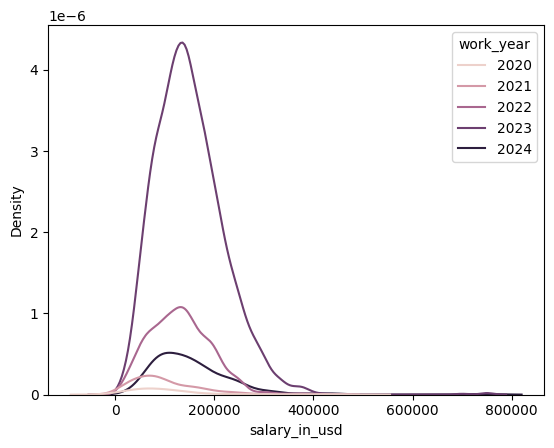

In [26]:
import seaborn as sns
sns.kdeplot(data=df, x="salary_in_usd", hue="work_year")

In [31]:
df["salary_to_gdp_ratio"] = df["salary_in_usd"] / df["salary_to_gdp_ratio"]

KeyError: 'salary_to_gdp_ratio'